<a href="https://colab.research.google.com/github/AlankrithaS/-Data-Visualization-Streamlit/blob/main/pyspark1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pyspark notebook


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 5.6 MB/s eta 0:00:00


In [2]:
from pyspark.sql import SparkSession

In [3]:
from pyspark.sql.functions import *

In [5]:
from pyspark.sql import SparkSession

# Create a SparkSession
spark = SparkSession.builder.appName("BigMartSalesAnalysis").getOrCreate()

df = spark.read.format('csv')\
    .option('header',True)\
    .option('inferSchema',True)\
    .load('/content/BigMartSales.csv')

In [6]:
display(df)

DataFrame[Item_Identifier: string, Item_Weight: double, Item_Fat_Content: string, Item_Visibility: double, Item_Type: string, Item_MRP: double, Outlet_Identifier: string, Outlet_Establishment_Year: int, Outlet_Size: string, Outlet_Location_Type: string, Outlet_Type: string, Item_Outlet_Sales: double]

In [7]:
df.show()

+---------------+-----------+----------------+---------------+--------------------+--------+-----------------+-------------------------+-----------+--------------------+-----------------+-----------------+
|Item_Identifier|Item_Weight|Item_Fat_Content|Item_Visibility|           Item_Type|Item_MRP|Outlet_Identifier|Outlet_Establishment_Year|Outlet_Size|Outlet_Location_Type|      Outlet_Type|Item_Outlet_Sales|
+---------------+-----------+----------------+---------------+--------------------+--------+-----------------+-------------------------+-----------+--------------------+-----------------+-----------------+
|          FDA15|        9.3|         Low Fat|    0.016047301|               Dairy|249.8092|           OUT049|                     1999|     Medium|              Tier 1|Supermarket Type1|         3735.138|
|          DRC01|       5.92|         Regular|    0.019278216|         Soft Drinks| 48.2692|           OUT018|                     2009|     Medium|              Tier 3|Superma

In [8]:
df.printSchema()

root
 |-- Item_Identifier: string (nullable = true)
 |-- Item_Weight: double (nullable = true)
 |-- Item_Fat_Content: string (nullable = true)
 |-- Item_Visibility: double (nullable = true)
 |-- Item_Type: string (nullable = true)
 |-- Item_MRP: double (nullable = true)
 |-- Outlet_Identifier: string (nullable = true)
 |-- Outlet_Establishment_Year: integer (nullable = true)
 |-- Outlet_Size: string (nullable = true)
 |-- Outlet_Location_Type: string (nullable = true)
 |-- Outlet_Type: string (nullable = true)
 |-- Item_Outlet_Sales: double (nullable = true)



In [ ]:
my_ddl_Schema='''     Item_Identifier DOUBLE,
        Item_Weight DOUBLE,
        Item_Fat_Content DOUBLE,
        Item_Visibility DOUBLE,
        Item_Type DOUBLE,
        Item_MRP DOUBLE,
        Outlet_Identifier DOUBLE,
        Outlet_Establishment_Year INT,
        Outlet_Size DOUBLE,
        Outlet_Location_Type DOUBLE,
        Outlet_Type DOUBLE,
        Item_Outlet_Sales DOUBLE
'''


In [ ]:
df= spark.read.format('csv')\
      .schema(my_ddl_Schema)\
      .option('header',True)\
      .load('/content/BigMartSales.csv')

In [ ]:
display(df)

In [ ]:
df=spark.read.format('csv')\
        .option('header',True)\
        .option('inferSchema',True)\
        .load('/content/BigMartSales.csv')

df.show()

In [ ]:
df.printSchema()

In [ ]:
from pyspark.sql.functions import *
from pyspark.sql.types import *

**SELECT**

In [ ]:
df.show()

In [ ]:
df_sel=df.select('Item_Identifier','Item_Weight','Item_Fat_Content')

In [ ]:
df_sel.show()

In [ ]:
df_sel=df.select(col('Item_Identifier'),col('Item_Weight'),col('Item_Fat_Content'))
df_sel.show()

**ALIAS**

In [ ]:
df_alias= df.select(col('Item_Identifier').alias('Item_id'))
df_alias.show()

**FLITER/WHERE**
Used for slicing our data as this is low level slicing

**FILER**

In [ ]:
df.show()

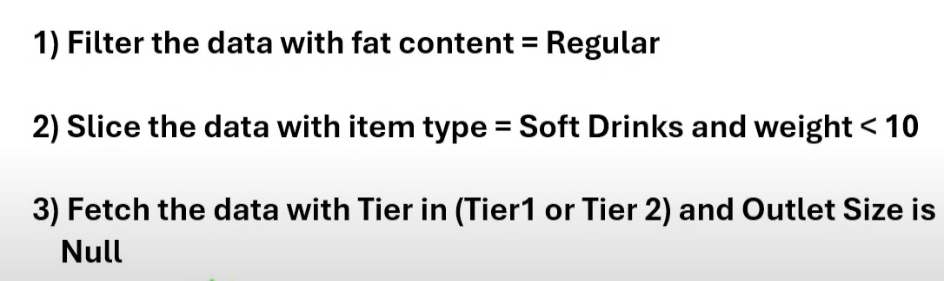***

***Senario 1***

In [ ]:
df.filter(col('Item_Fat_Content')=='Low Fat').show()

***Senario 2***

In [ ]:
df.filter((col('Item_Weight')<10) & (col('Item_Type')=='Dairy')).show()

***Senario 3***

In [ ]:
df.filter((col('Outlet_Location_Type').isin('Tier 1','Tier 2')) & (col('Outlet_Size').isNull())).show()

**With-Column-Rename**

*By using withcol rename it changes the col name in dataframe level*

In [11]:
#with alias
df.select(col('Item_Weight').alias('item_wt')).show()

+-------+
|item_wt|
+-------+
|    9.3|
|   5.92|
|   17.5|
|   19.2|
|   8.93|
| 10.395|
|  13.65|
|   NULL|
|   16.2|
|   19.2|
|   11.8|
|   18.5|
|   15.1|
|   17.6|
|  16.35|
|    9.0|
|   11.8|
|    9.0|
|   NULL|
|  13.35|
+-------+
only showing top 20 rows



In [12]:
#withcolrename
df.withColumnRenamed('Item_Weight','itm_wt').show()

+---------------+------+----------------+---------------+--------------------+--------+-----------------+-------------------------+-----------+--------------------+-----------------+-----------------+
|Item_Identifier|itm_wt|Item_Fat_Content|Item_Visibility|           Item_Type|Item_MRP|Outlet_Identifier|Outlet_Establishment_Year|Outlet_Size|Outlet_Location_Type|      Outlet_Type|Item_Outlet_Sales|
+---------------+------+----------------+---------------+--------------------+--------+-----------------+-------------------------+-----------+--------------------+-----------------+-----------------+
|          FDA15|   9.3|         Low Fat|    0.016047301|               Dairy|249.8092|           OUT049|                     1999|     Medium|              Tier 1|Supermarket Type1|         3735.138|
|          DRC01|  5.92|         Regular|    0.019278216|         Soft Drinks| 48.2692|           OUT018|                     2009|     Medium|              Tier 3|Supermarket Type2|         443.4

**withColumn**

***Senario***

Senario 1 : *Creating new column = new_col*

Senario 2 : *Modify the existing column = modify_col*

Senario 3 : *Teansformation on new col*


In [13]:
df.show()

+---------------+-----------+----------------+---------------+--------------------+--------+-----------------+-------------------------+-----------+--------------------+-----------------+-----------------+
|Item_Identifier|Item_Weight|Item_Fat_Content|Item_Visibility|           Item_Type|Item_MRP|Outlet_Identifier|Outlet_Establishment_Year|Outlet_Size|Outlet_Location_Type|      Outlet_Type|Item_Outlet_Sales|
+---------------+-----------+----------------+---------------+--------------------+--------+-----------------+-------------------------+-----------+--------------------+-----------------+-----------------+
|          FDA15|        9.3|         Low Fat|    0.016047301|               Dairy|249.8092|           OUT049|                     1999|     Medium|              Tier 1|Supermarket Type1|         3735.138|
|          DRC01|       5.92|         Regular|    0.019278216|         Soft Drinks| 48.2692|           OUT018|                     2009|     Medium|              Tier 3|Superma

In [19]:
df.withColumn('type',lit('new')).show()

+---------------+-----------+----------------+---------------+--------------------+--------+-----------------+-------------------------+-----------+--------------------+-----------------+-----------------+----+
|Item_Identifier|Item_Weight|Item_Fat_Content|Item_Visibility|           Item_Type|Item_MRP|Outlet_Identifier|Outlet_Establishment_Year|Outlet_Size|Outlet_Location_Type|      Outlet_Type|Item_Outlet_Sales|type|
+---------------+-----------+----------------+---------------+--------------------+--------+-----------------+-------------------------+-----------+--------------------+-----------------+-----------------+----+
|          FDA15|        9.3|         Low Fat|    0.016047301|               Dairy|249.8092|           OUT049|                     1999|     Medium|              Tier 1|Supermarket Type1|         3735.138| new|
|          DRC01|       5.92|         Regular|    0.019278216|         Soft Drinks| 48.2692|           OUT018|                     2009|     Medium|        

In [20]:
df.withColumn('multiple',(col('Item_Weight')*col('Item_Visibility'))).show()

+---------------+-----------+----------------+---------------+--------------------+--------+-----------------+-------------------------+-----------+--------------------+-----------------+-----------------+-------------------+
|Item_Identifier|Item_Weight|Item_Fat_Content|Item_Visibility|           Item_Type|Item_MRP|Outlet_Identifier|Outlet_Establishment_Year|Outlet_Size|Outlet_Location_Type|      Outlet_Type|Item_Outlet_Sales|           multiple|
+---------------+-----------+----------------+---------------+--------------------+--------+-----------------+-------------------------+-----------+--------------------+-----------------+-----------------+-------------------+
|          FDA15|        9.3|         Low Fat|    0.016047301|               Dairy|249.8092|           OUT049|                     1999|     Medium|              Tier 1|Supermarket Type1|         3735.138|       0.1492398993|
|          DRC01|       5.92|         Regular|    0.019278216|         Soft Drinks| 48.2692|    

In [25]:
df.withColumn('Item_Fat_Content',regexp_replace(col('Item_Fat_Content'),'Regular','Reg'))\
   .withColumn('Item_Fat_Content',regexp_replace(col('Item_Fat_Content'),'Low Fat','LF')).show()


+---------------+-----------+----------------+---------------+--------------------+--------+-----------------+-------------------------+-----------+--------------------+-----------------+-----------------+
|Item_Identifier|Item_Weight|Item_Fat_Content|Item_Visibility|           Item_Type|Item_MRP|Outlet_Identifier|Outlet_Establishment_Year|Outlet_Size|Outlet_Location_Type|      Outlet_Type|Item_Outlet_Sales|
+---------------+-----------+----------------+---------------+--------------------+--------+-----------------+-------------------------+-----------+--------------------+-----------------+-----------------+
|          FDA15|        9.3|              LF|    0.016047301|               Dairy|249.8092|           OUT049|                     1999|     Medium|              Tier 1|Supermarket Type1|         3735.138|
|          DRC01|       5.92|             Reg|    0.019278216|         Soft Drinks| 48.2692|           OUT018|                     2009|     Medium|              Tier 3|Superma

**Type Casting**

this seems not to be reflecting on the dataframe level

In [32]:
df.withColumn('Item_Weight', col('Item_Weight').cast(StringType()) ).printSchema()

root
 |-- Item_Identifier: string (nullable = true)
 |-- Item_Weight: string (nullable = true)
 |-- Item_Fat_Content: string (nullable = true)
 |-- Item_Visibility: double (nullable = true)
 |-- Item_Type: string (nullable = true)
 |-- Item_MRP: double (nullable = true)
 |-- Outlet_Identifier: string (nullable = true)
 |-- Outlet_Establishment_Year: integer (nullable = true)
 |-- Outlet_Size: string (nullable = true)
 |-- Outlet_Location_Type: string (nullable = true)
 |-- Outlet_Type: string (nullable = true)
 |-- Item_Outlet_Sales: double (nullable = true)



In [33]:
df.printSchema()

root
 |-- Item_Identifier: string (nullable = true)
 |-- Item_Weight: double (nullable = true)
 |-- Item_Fat_Content: string (nullable = true)
 |-- Item_Visibility: double (nullable = true)
 |-- Item_Type: string (nullable = true)
 |-- Item_MRP: double (nullable = true)
 |-- Outlet_Identifier: string (nullable = true)
 |-- Outlet_Establishment_Year: integer (nullable = true)
 |-- Outlet_Size: string (nullable = true)
 |-- Outlet_Location_Type: string (nullable = true)
 |-- Outlet_Type: string (nullable = true)
 |-- Item_Outlet_Sales: double (nullable = true)



**Sort**